In [75]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors

In [76]:
data = pd.read_csv('Credit_Card_Transactions.csv') 
data.head()

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud,merch_zipcode
0,0,2019-07-09 18:13:51,3284636877601489,"fraud_Kutch, Hermiston and Farrell",misc_pos,132.08,Jennifer,Garcia,M,8446 Main St,...,-87.584542,498767,Engineer,1955-08-06,89a9258d509ecdde653fd58773bbf4d5,1562696031,37.098534,-87.924192,0,NaN
1,1,2019-02-11 20:57:50,1806999087872028,fraud_Keeling-Crist,gas_transport,477.84,Sarah,Gill,M,8956 Main St,...,-79.871627,519400,Psychologist,1998-08-11,3de41927d38ff34f2f8ba2ef2f767952,1549918670,46.772532,-79.419724,0,NaN
2,2,2019-04-13 14:55:05,8393811742409058,fraud_Lind-Buckridge,shopping_pos,383.77,Emma,Patel,F,7761 Main St,...,-118.746926,979658,Teacher,1983-11-02,9f1e2345a0e6c66aba288a9fb7198312,1555167305,31.047227,-118.722704,0,75963.0
3,3,2019-07-23 11:47:45,1331000517753595,fraud_Keeling-Crist,gas_transport,382.24,David,Singh,M,901 Main St,...,-120.140961,641946,Nurse,1993-07-31,4f00c594f6429cbbe92b93081d3dea0f,1563882465,33.734276,-119.854263,0,NaN
4,4,2019-04-07 12:49:51,3945556355009753,"fraud_Rippin, Kub and Mann",shopping_pos,494.90,David,Sanchez,M,4161 Main St,...,-106.084451,482230,Engineer,1976-05-06,efa07f4ada9893e36a51e2f38466cfa0,1554641391,40.385343,-105.829959,0,15584.0


trans_date_trans_time is a datetime string, and scatter plots work best with numeric values on both axes. Convert the column to datetime

In [77]:
#Use errors='coerce' so pandas converts bad values to NaT instead of crashing.
# Parse datetime + drop bad rows
data["trans_date_trans_time"] = pd.to_datetime(data["trans_date_trans_time"], errors="coerce")
data = data.dropna(subset=["trans_date_trans_time"]).copy()

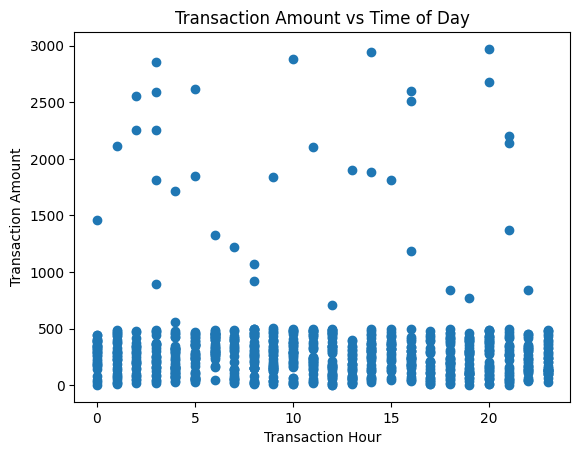

In [94]:
plt.scatter(data['trans_hour'], data['amt'])
plt.xlabel("Transaction Hour")
plt.ylabel("Transaction Amount")
plt.title("Transaction Amount vs Time of Day")
plt.show()

In [95]:
# create numeric time feature
data["trans_hour"] = data["trans_date_trans_time"].dt.hour

features = data[['amt', 'trans_hour']] #updating features

Scaling Features

In [96]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(features)

 Implement Isolation Forest

In [97]:
# Isolation Forest
iso = IsolationForest(n_estimators=300, contamination=0.02, random_state=42, n_jobs=-1)
pred = iso.fit_predict(X_scaled)   # fit + predict in one step

In [98]:
pred ## Output: -1 = anomaly, 1 = normal

array([ 1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1, -1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1, -1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1, -1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1, -1,  1,  1,  1,  1, -1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1, -1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1

Add Anomaly Labels Back to the DataFrame

In [99]:
data['anomaly'] = pred

normalize -1 and 1 from predictions, after normalization, below, 0 means normal and 1 means anomaly

In [100]:
# Convert: -1 -> 1 (anomaly), 1 -> 0 (normal)
data["anomaly"] = (pred == -1).astype(int)

In [101]:
data.head()

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud,merch_zipcode,trans_hour,anomaly
0,0,2019-07-09 18:13:51,3284636877601489,"fraud_Kutch, Hermiston and Farrell",misc_pos,132.08,Jennifer,Garcia,M,8446 Main St,...,Engineer,1955-08-06,89a9258d509ecdde653fd58773bbf4d5,1562696031,37.098534,-87.924192,0,NaN,18,0
1,1,2019-02-11 20:57:50,1806999087872028,fraud_Keeling-Crist,gas_transport,477.84,Sarah,Gill,M,8956 Main St,...,Psychologist,1998-08-11,3de41927d38ff34f2f8ba2ef2f767952,1549918670,46.772532,-79.419724,0,NaN,20,0
2,2,2019-04-13 14:55:05,8393811742409058,fraud_Lind-Buckridge,shopping_pos,383.77,Emma,Patel,F,7761 Main St,...,Teacher,1983-11-02,9f1e2345a0e6c66aba288a9fb7198312,1555167305,31.047227,-118.722704,0,75963.0,14,0
3,3,2019-07-23 11:47:45,1331000517753595,fraud_Keeling-Crist,gas_transport,382.24,David,Singh,M,901 Main St,...,Nurse,1993-07-31,4f00c594f6429cbbe92b93081d3dea0f,1563882465,33.734276,-119.854263,0,NaN,11,0
4,4,2019-04-07 12:49:51,3945556355009753,"fraud_Rippin, Kub and Mann",shopping_pos,494.90,David,Sanchez,M,4161 Main St,...,Engineer,1976-05-06,efa07f4ada9893e36a51e2f38466cfa0,1554641391,40.385343,-105.829959,0,15584.0,12,0


split the data

In [102]:
normal = data[data['anomaly'] == 0]
anomaly_exists = data[data['anomaly'] == 1]

In [103]:
normal.head()

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud,merch_zipcode,trans_hour,anomaly
0,0,2019-07-09 18:13:51,3284636877601489,"fraud_Kutch, Hermiston and Farrell",misc_pos,132.08,Jennifer,Garcia,M,8446 Main St,...,Engineer,1955-08-06,89a9258d509ecdde653fd58773bbf4d5,1562696031,37.098534,-87.924192,0,NaN,18,0
1,1,2019-02-11 20:57:50,1806999087872028,fraud_Keeling-Crist,gas_transport,477.84,Sarah,Gill,M,8956 Main St,...,Psychologist,1998-08-11,3de41927d38ff34f2f8ba2ef2f767952,1549918670,46.772532,-79.419724,0,NaN,20,0
2,2,2019-04-13 14:55:05,8393811742409058,fraud_Lind-Buckridge,shopping_pos,383.77,Emma,Patel,F,7761 Main St,...,Teacher,1983-11-02,9f1e2345a0e6c66aba288a9fb7198312,1555167305,31.047227,-118.722704,0,75963.0,14,0
3,3,2019-07-23 11:47:45,1331000517753595,fraud_Keeling-Crist,gas_transport,382.24,David,Singh,M,901 Main St,...,Nurse,1993-07-31,4f00c594f6429cbbe92b93081d3dea0f,1563882465,33.734276,-119.854263,0,NaN,11,0
4,4,2019-04-07 12:49:51,3945556355009753,"fraud_Rippin, Kub and Mann",shopping_pos,494.90,David,Sanchez,M,4161 Main St,...,Engineer,1976-05-06,efa07f4ada9893e36a51e2f38466cfa0,1554641391,40.385343,-105.829959,0,15584.0,12,0


In [104]:
anomaly_exists.head()

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud,merch_zipcode,trans_hour,anomaly
28,28,2019-08-16 20:17:30,7965820931466854,"fraud_Heller, Gutmann and Zieme",food_dining,2679.73,Jennifer,Patel,F,281 Main St,...,Accountant,1950-02-18,8662fd0f8499cd2ab617bc9885ff85bd,1565986650,34.208850,-78.267393,1,97355.0,20,1
48,48,2019-07-13 03:44:52,3248601088957131,"fraud_Rippin, Kub and Mann",entertainment,2593.65,Jeremy,Patel,M,6580 Main St,...,Nurse,1970-03-22,7546f37fa2526ef0bd59593a91af51ab,1562989492,47.917371,-103.423666,1,NaN,3,1
75,75,2019-05-20 20:06:24,723162158663545,fraud_Lind-Buckridge,misc_pos,2972.22,Stephanie,Garcia,M,3827 Main St,...,Accountant,1998-05-20,98970e98dfc607ca941cc837c6d35837,1558382784,46.305734,-100.828246,1,63413.0,20,1
95,95,2019-08-08 00:49:43,8322871682998693,fraud_Keeling-Crist,entertainment,1459.56,Jeremy,Banks,F,4112 Main St,...,Manager,1955-10-22,f12c6ae59d2a0d3c3691a51c8c85cbcc,1565225383,30.666022,-98.136137,1,47770.0,0,1
100,100,2019-01-21 14:15:34,9577459720883552,"fraud_Rippin, Kub and Mann",food_dining,2948.62,Emma,White,M,4589 Main St,...,Driver,2000-10-11,ad9ff0c92ac8f2e11e63108effb053ea,1548080134,25.012233,-78.821147,1,48400.0,14,1


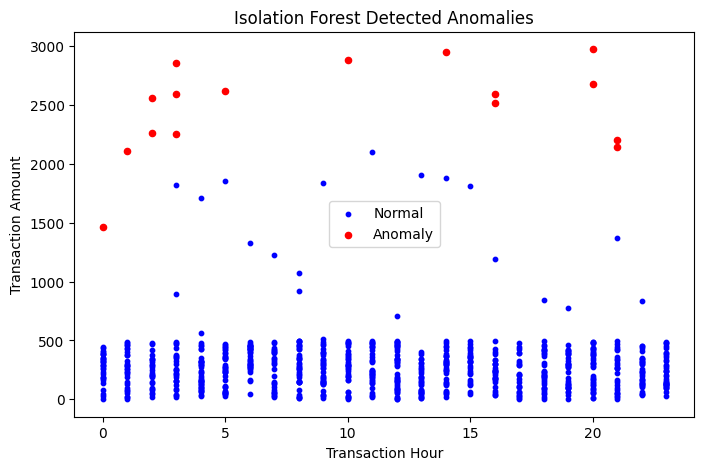

In [105]:
plt.figure(figsize=(8,5))

plt.scatter(normal['trans_hour'], normal['amt'], c='blue', s=10, label='Normal')
plt.scatter(anomaly_exists['trans_hour'], anomaly_exists['amt'], c='red', s=20, label='Anomaly')

plt.xlabel("Transaction Hour")
plt.ylabel("Transaction Amount")
plt.title("Isolation Forest Detected Anomalies")
plt.legend()

plt.show()